# Analisis Komparatif Algoritma Klasifikasi Sentimen dalam Mengukur Kesesuaian Star Rating dan Ulasan Pengguna Menggunakan Visualisasi Analitik
## Eksperimen: Multinomial NB, Linear SVM, & Logistic Regression
### Dataset: Google Play Store Reviews (12,495 Rows)

Notebook ini dirancang untuk memberikan analisis komprehensif mulai dari pemahaman data (EDA) hingga evaluasi model mendalam menggunakan dataset skala menengah yang kredibel secara akademik.

### 1. Inisialisasi dan Pemuatan Data

In [1]:
import pandas as pd
import numpy as np
import re
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    balanced_accuracy_score, f1_score
)
from imblearn.over_sampling import RandomOverSampler

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (12, 8)

/var/www/html/analisis-kesesuaian-antara-star-rating-dan-sentimen-ulasan-pengguna-menggunakan-metode-naive-bayes/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mikeudev/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/mikeudev/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# Download dataset baru (12k+ rows)
path = kagglehub.dataset_download("prakharrathi25/google-play-store-reviews")
df_raw = pd.read_csv(f"{path}/reviews.csv")

# Preprocessing kolom agar sesuai dengan pipeline sebelumnya
df = df_raw[['content', 'score']].copy()
df = df.dropna(subset=['content']).rename(columns={"content": "review", "score": "star_rating"})

# Mapping Sentiment
df['sentiment'] = df['star_rating'].apply(lambda x:
    'positive' if x >= 4 else 'neutral' if x == 3 else 'negative'
)

df['review_len'] = df['review'].apply(lambda x: len(str(x)))
print(f"Dataset Loaded: {len(df)} rows")

Dataset Loaded: 12495 rows


### 2. Exploratory Data Analysis (EDA)

/tmp/ipykernel_4823/1641250262.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='star_rating', data=df, ax=ax[0], palette='magma')


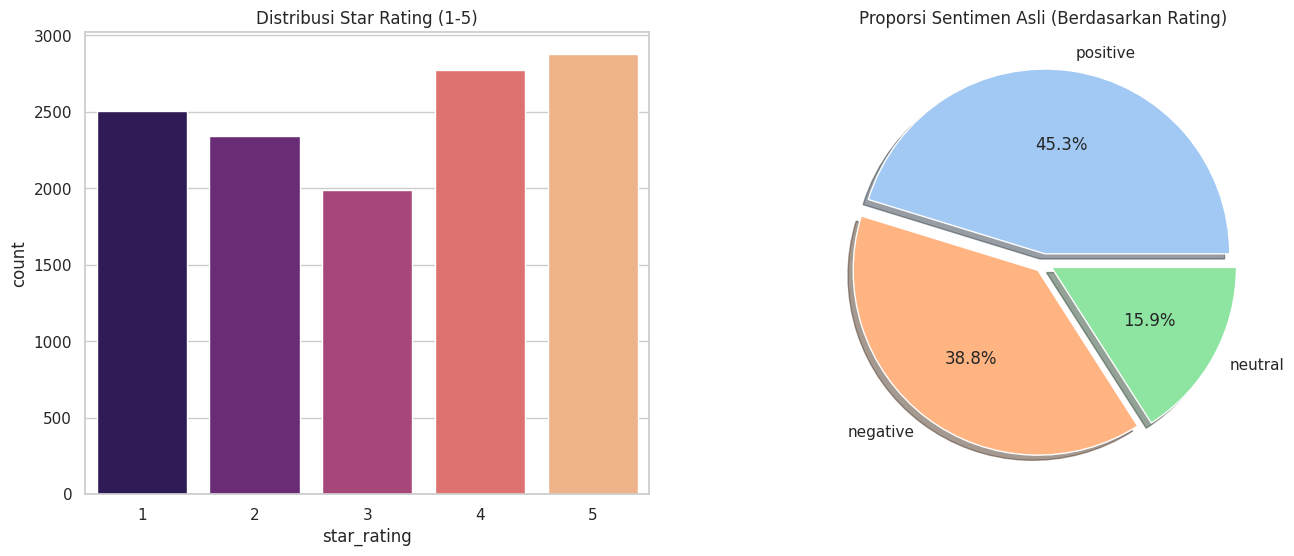

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribusi Star Rating
sns.countplot(x='star_rating', data=df, ax=ax[0], palette='magma')
ax[0].set_title('Distribusi Star Rating (1-5)')

# 2. Distribusi Sentimen
df['sentiment'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1], explode=[0.05]*3, shadow=True)
ax[1].set_title('Proporsi Sentimen Asli (Berdasarkan Rating)')
plt.show()

### 3. Text Preprocessing & TF-IDF

In [4]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-z\s]', '', str(text).lower())
    return " ".join([lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words])

df['clean_review'] = df['review'].apply(clean_text)

In [5]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Balancing Data
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(dual=False)
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test)
    results[name] = preds
    print(f"--- {name} Results ---")
    print(classification_report(y_test, preds))


--- Naive Bayes Results ---
              precision    recall  f1-score   support

    negative       0.70      0.71      0.71       970
     neutral       0.27      0.36      0.31       398
    positive       0.83      0.72      0.77      1131

    accuracy                           0.66      2499
   macro avg       0.60      0.60      0.60      2499
weighted avg       0.69      0.66      0.67      2499

--- Logistic Regression Results ---
              precision    recall  f1-score   support

    negative       0.71      0.73      0.72       970
     neutral       0.30      0.36      0.33       398
    positive       0.82      0.74      0.78      1131

    accuracy                           0.68      2499
   macro avg       0.61      0.61      0.61      2499
weighted avg       0.70      0.68      0.69      2499

--- Linear SVM Results ---
              precision    recall  f1-score   support

    negative       0.72      0.69      0.70       970
     neutral       0.28      0.33     

### 4. Analisis Kesesuaian (Mismatch Analysis) & Tableau Export

In [6]:
# Memilih model terbaik (misal Logistic Regression)
best_model_name = "Logistic Regression"
y_pred = results[best_model_name]

mismatch_df = df.iloc[y_test.index].copy()
mismatch_df['predicted_sentiment'] = y_pred
mismatch_df['is_correct'] = mismatch_df['sentiment'] == mismatch_df['predicted_sentiment']

# Simpan untuk Tableau
mismatch_df.to_csv("tableau_playstore_analysis.csv", index=False)
print("Data 12k ulasan berhasil diekspor untuk Tableau!")

Data 12k ulasan berhasil diekspor untuk Tableau!
